In [2]:
# Imports
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar el root del proyecto al path
sys.path.append(os.path.abspath(".."))

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Carga de datos
from src.data.load_data import load_data

df = load_data("../data/raw/german.data")

# Preview
df.head()

,status,duration,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_of_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
df['target'].value_counts(normalize=True)

target
1    0.7
2    0.3
Name: proportion, dtype: float64

In [4]:
df.head()

,status,duration,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_of_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
df.shape

(1000, 21)

In [6]:
df.dtypes

status                     object
duration                    int64
credit_history             object
purpose                    object
credit_amount               int64
savings                    object
employment_duration        object
installment_rate            int64
personal_status_sex        object
other_debtors              object
present_residence           int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
number_of_credits           int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
target                      int64
dtype: object

In [7]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['duration', 'credit_amount', 'installment_rate', 'present_residence', 'age', 'number_of_credits', 'people_liable', 'target']
Categorical: ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [8]:
df['target'].value_counts()
df['target'].value_counts(normalize=True)

target
1    0.7
2    0.3
Name: proportion, dtype: float64

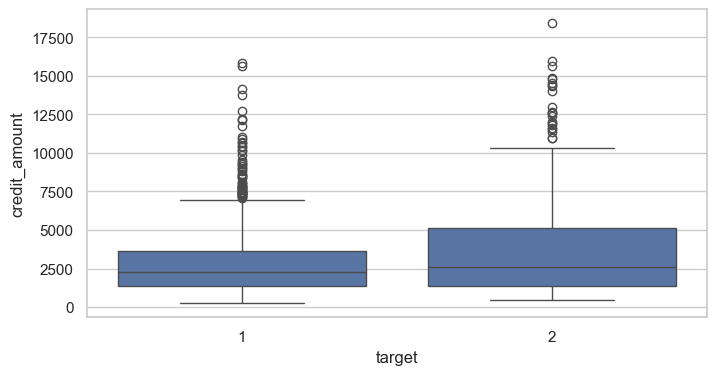

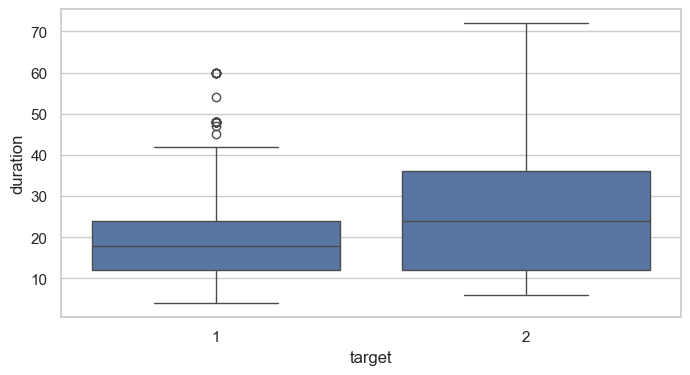

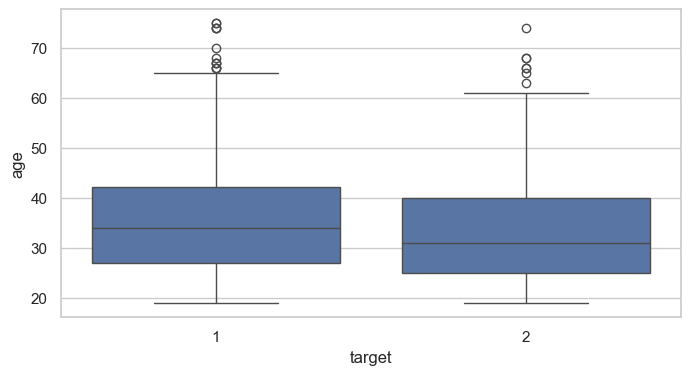

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='target', y='credit_amount', data=df)
plt.show()

sns.boxplot(x='target', y='duration', data=df)
plt.show()

sns.boxplot(x='target', y='age', data=df)
plt.show()

In [10]:
pd.crosstab(df['housing'], df['target'], normalize='index')

target,1,2
housing,,
A151,0.608939,0.391061
A152,0.739130,0.260870
A153,0.592593,0.407407


In [11]:
pd.crosstab(df['credit_history'], df['target'], normalize='index')

target,1,2
credit_history,,
A30,0.375000,0.625000
A31,0.428571,0.571429
A32,0.681132,0.318868
A33,0.681818,0.318182
A34,0.829352,0.170648


In [12]:
df.groupby('target')[['credit_amount', 'duration', 'age']].mean()

,credit_amount,duration,age
target,,,
1,2985.457143,19.207143,36.224286
2,3938.126667,24.860000,33.963333
